In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import numpy as np
from matplotlib.dates import DateFormatter
import warnings
warnings.filterwarnings('ignore')


In [2]:
client = MongoClient('mongodb://localhost:27017/')

db = client["Retali_Business"]

orders_col = db["Orders"]

In [21]:
 pipeline = [
        {
            "$group": {
                "_id": "$customer.id",
                "customerName": {"$first": "$customer.name"},
                "totalSpent": {"$sum": "$sale.total_amount"},
                "transactionCount": {"$sum": 1}
            }
        },
        {"$sort": {"totalSpent": -1}},
        {"$limit": 10}
    ]

In [ ]:
def get_data(filter={}):
    try:
        data = []
        for doc in orders_col.find(filter):
            doc['_id'] = str(doc['_id'])
            data.append(doc)
        return True, data

    except Exception as e:
        return False, str(e)

In [ ]:
success, data = get_data(pipeline)
print(success)
print(data)  # Print first 2 records for brevity

False
filter must be an instance of dict, bson.son.SON, or any other type that inherits from collections.Mapping


In [24]:
results = list(orders_col.aggregate(pipeline))

In [25]:
print(results)

[{'_id': 12399, 'customerName': 'Mariam Ibrahim', 'totalSpent': 457363.16, 'transactionCount': 42}, {'_id': 5042, 'customerName': 'Ali Ibrahim', 'totalSpent': 443270.87, 'transactionCount': 39}, {'_id': 8636, 'customerName': 'Mariam Youssef', 'totalSpent': 433441.19, 'transactionCount': 47}, {'_id': 3051, 'customerName': 'Hoda Youssef', 'totalSpent': 420328.42, 'transactionCount': 35}, {'_id': 7287, 'customerName': 'Mariam Mahmoud', 'totalSpent': 415659.87, 'transactionCount': 38}, {'_id': 237, 'customerName': 'Menna Kamel', 'totalSpent': 412337.63, 'transactionCount': 51}, {'_id': 10715, 'customerName': 'Mahmoud Ali', 'totalSpent': 403088.0, 'transactionCount': 47}, {'_id': 7664, 'customerName': 'Ahmed Kamel', 'totalSpent': 402106.78, 'transactionCount': 35}, {'_id': 17491, 'customerName': 'Menna Mahmoud', 'totalSpent': 382787.61, 'transactionCount': 37}, {'_id': 10099, 'customerName': 'Khaled Kamel', 'totalSpent': 378493.29, 'transactionCount': 35}]


In [27]:
 df = pd.DataFrame(results)

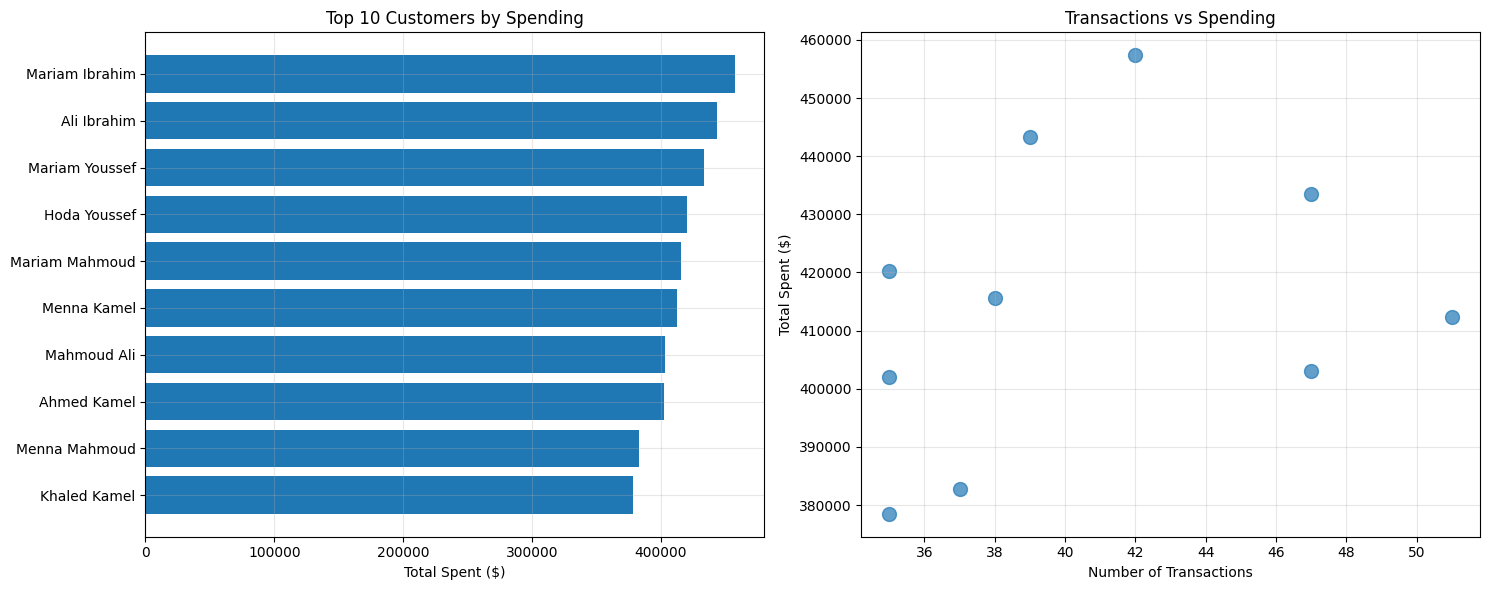

In [29]:
# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Horizontal bar chart
df_sorted = df.sort_values('totalSpent')
ax1.barh(df_sorted['customerName'], df_sorted['totalSpent'])
ax1.set_xlabel('Total Spent ($)')
ax1.set_title('Top 10 Customers by Spending')
ax1.grid(True, alpha=0.3)

# Scatter plot: Transactions vs Spending
ax2.scatter(df['transactionCount'], df['totalSpent'], s=100, alpha=0.7)
ax2.set_xlabel('Number of Transactions')
ax2.set_ylabel('Total Spent ($)')
ax2.set_title('Transactions vs Spending')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()